# Températures et risque de pluie sur 5 jours

Les zones bleues indiquent les créneaux où l'écart entre la température et le point de rosée est inférieur ou égal à 4 °C. C'est un indicateur de risque d'humidité/nuages, pas une prévision de pluie certaine.

In [1]:
import json
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

FICHIER_METEO = Path(r'Y:/Documents/5days.txt')
SEUIL_RISQUE_PLUIE = 4  # °C : température - point de rosée

with FICHIER_METEO.open(encoding='utf-8') as fichier:
    meteo = pd.DataFrame(json.load(fichier))

colonnes = {'dt', 'temp', 'dew_point'}
manquantes = colonnes - set(meteo.columns)
if manquantes:
    raise ValueError(f'Colonnes absentes du fichier : {sorted(manquantes)}')

meteo['date'] = pd.to_datetime(meteo['dt'], unit='s', utc=True).dt.tz_convert('Europe/Paris').dt.tz_localize(None)
meteo['ecart_rosee'] = meteo['temp'] - meteo['dew_point']
meteo['risque_pluie'] = meteo['ecart_rosee'] <= SEUIL_RISQUE_PLUIE
meteo[['date', 'temp', 'dew_point', 'ecart_rosee', 'risque_pluie']]

,date,temp,dew_point,ecart_rosee,risque_pluie
0,2026-08-24 23:00:00,21.07,10.26,10.81,False
1,2026-08-25 02:00:00,20.63,10.44,10.19,False
2,2026-08-25 05:00:00,18.68,14.57,4.11,False
3,2026-08-25 08:00:00,16.69,15.48,1.21,True
4,2026-08-25 11:00:00,20.04,13.83,6.21,False
5,2026-08-25 14:00:00,20.91,13.35,7.56,False
6,2026-08-25 17:00:00,26.00,13.26,12.74,False
7,2026-08-25 20:00:00,22.16,15.74,6.42,False
8,2026-08-25 23:00:00,20.93,16.50,4.43,False
9,2026-08-26 02:00:00,18.65,16.51,2.14,True


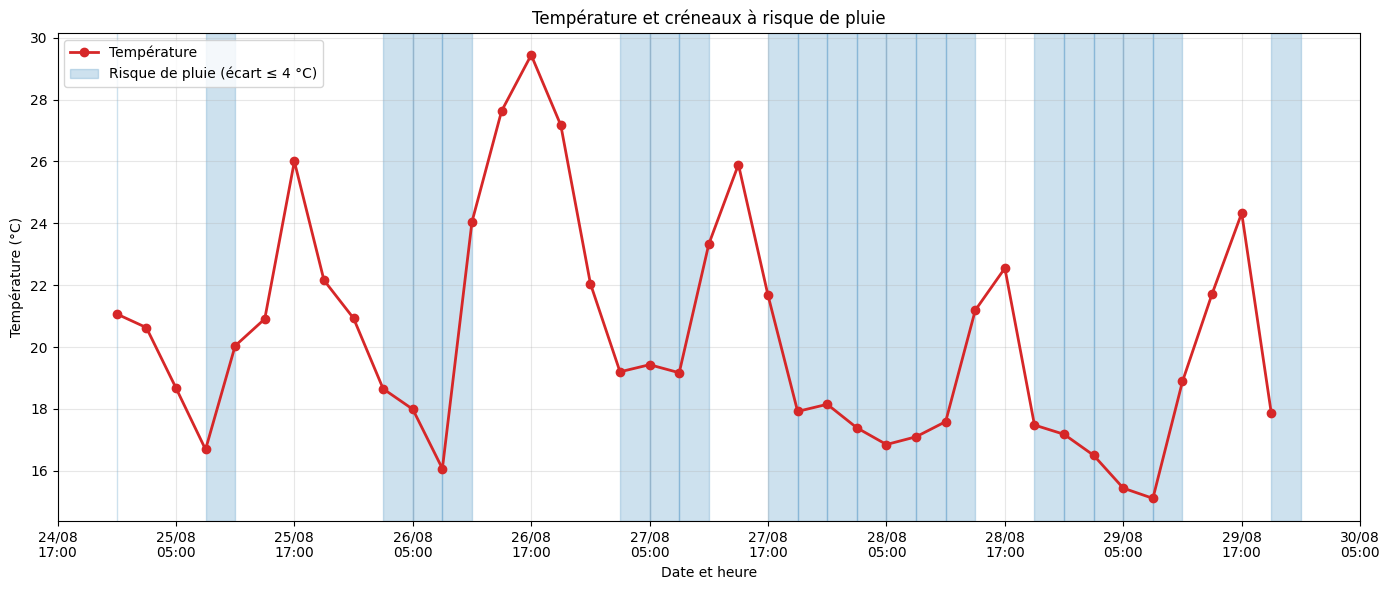

Créneaux bleus :


,date,temp,dew_point,ecart_rosee
3,2026-08-25 08:00:00,16.7,15.5,1.2
9,2026-08-26 02:00:00,18.6,16.5,2.1
10,2026-08-26 05:00:00,18.0,16.0,1.9
11,2026-08-26 08:00:00,16.1,15.0,1.0
17,2026-08-27 02:00:00,19.2,15.9,3.3
18,2026-08-27 05:00:00,19.4,16.7,2.8
19,2026-08-27 08:00:00,19.2,17.6,1.5
22,2026-08-27 17:00:00,21.7,18.5,3.2
23,2026-08-27 20:00:00,17.9,15.5,2.5
24,2026-08-27 23:00:00,18.2,15.5,2.7


In [2]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(meteo['date'], meteo['temp'], color='tab:red', marker='o', linewidth=2, label='Température')

# Chaque mesure couvre 3 heures dans le fichier de prévisions OpenWeather.
for _, ligne in meteo.loc[meteo['risque_pluie']].iterrows():
    ax.axvspan(ligne['date'], ligne['date'] + pd.Timedelta(hours=3), color='tab:blue', alpha=0.22)

# Entrée de légende pour les zones bleues.
ax.axvspan(meteo['date'].iloc[0], meteo['date'].iloc[0], color='tab:blue', alpha=0.22, label=f'Risque de pluie (écart ≤ {SEUIL_RISQUE_PLUIE} °C)')
ax.set_title('Température et créneaux à risque de pluie')
ax.set_xlabel('Date et heure')
ax.set_ylabel('Température (°C)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m\n%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=12))
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

print('Créneaux bleus :')
display(meteo.loc[meteo['risque_pluie'], ['date', 'temp', 'dew_point', 'ecart_rosee']].round({'temp': 1, 'dew_point': 1, 'ecart_rosee': 1}))